In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
from scipy import stats
import scanpy as sc
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors
import anndata

intersted_genes = ['Gpr101','Pdyn','Trhr','Tacr3','Shox2']
markergenes = ['Dbh', 'Th', 'Slc6a2']

import trimesh
mesh_LC = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/LC_ccf_v1_250102 2.obj")
mesh_CD = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/subCD_ccf_v1_250102 2.obj")
mesh_CV = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/subCV_ccf_v1_250102 2.obj")
allmeshes = [mesh_LC,mesh_CD,mesh_CV]

Duplicate key in file PosixPath('/home/shuonan.chen/miniconda3/envs/allensdk/lib/python3.8/site-packages/matplotlib/mpl-data/matplotlibrc'), line 271 ('font.sans-serif: DejaVu Sans, Bitstream Vera Sans, Computer Modern Sans Serif, Lucida Grande, Verdana, Geneva, Lucid, Arial, Helvetica, Avant Garde, sans-serif')


In [2]:
filename = '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/data/adata_mer_subset_2_6k.h5ad'
adata_mer = sc.read_h5ad(filename)

In [3]:
umap_random_state = 307
sc.pp.neighbors(adata_mer, use_rep="X_scVI",  random_state=umap_random_state)
sc.tl.umap(adata_mer, random_state=210)

/home/shuonan.chen/miniconda3/envs/allensdk/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/shuonan.chen/miniconda3/envs/allensdk/lib/python3.8/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12040. The TBB threading layer is disabled.
  warnings.warn(problem)


/home/shuonan.chen/miniconda3/envs/allensdk/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


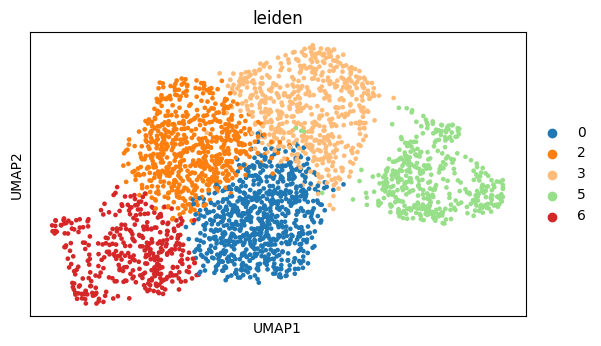

In [4]:
a = sc.pl.umap(adata_mer, color='leiden', show = False)
a.set_aspect('equal')

[None, None, None, None, None]

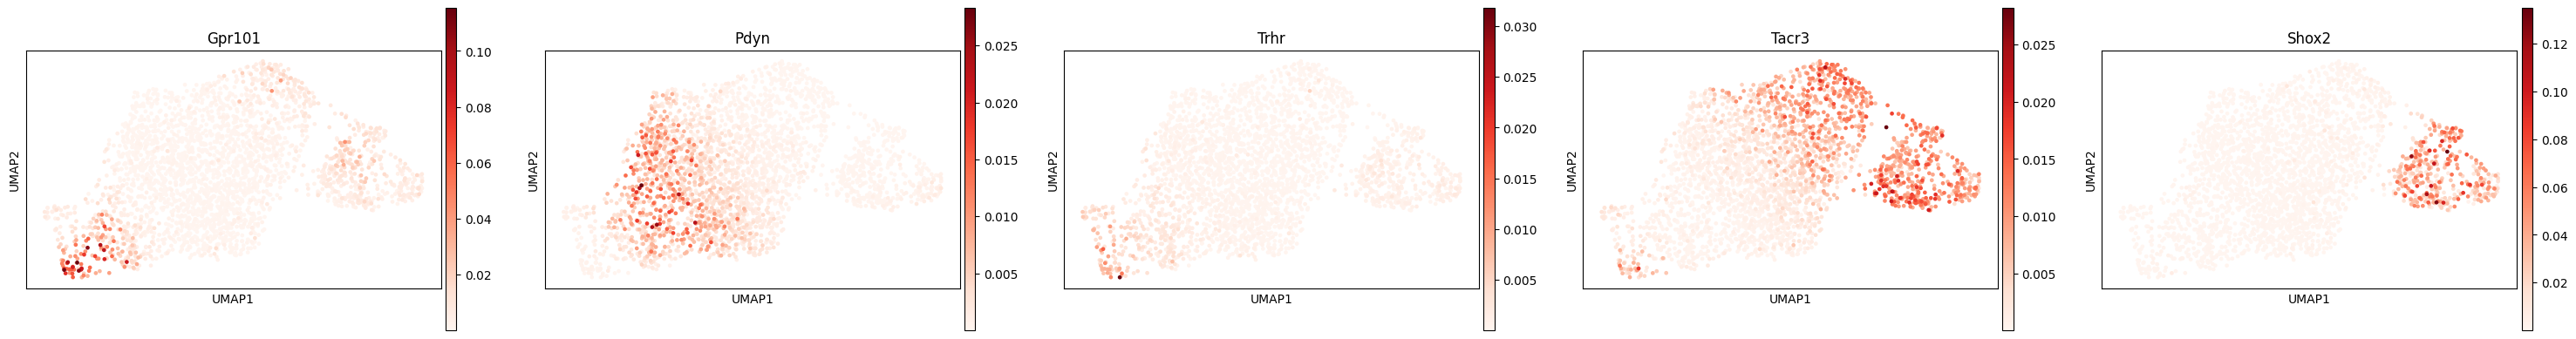

In [5]:
ax = sc.pl.umap(adata_mer, color=intersted_genes, show = False, cmap = 'Reds', ncols = 5)
[a.set_aspect('equal') for a in ax]

/scratch/fast/1339261/ipykernel_3756901/372882985.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/scratch/fast/1339261/ipykernel_3756901/372882985.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


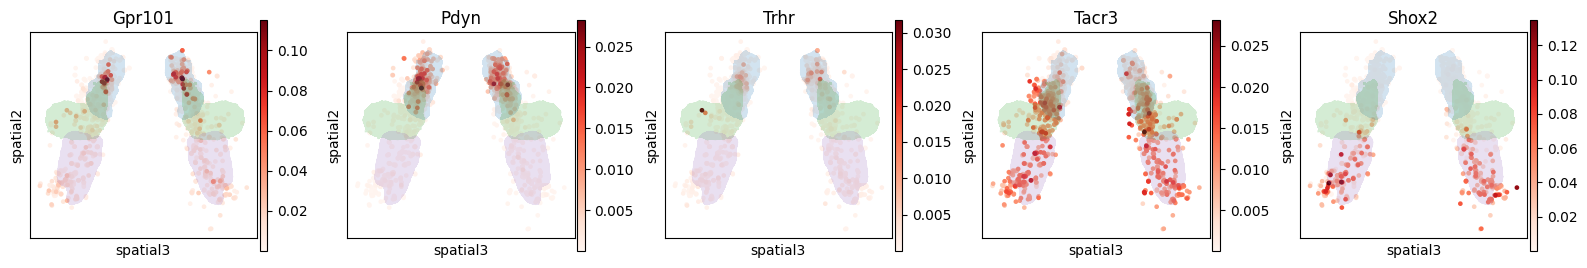

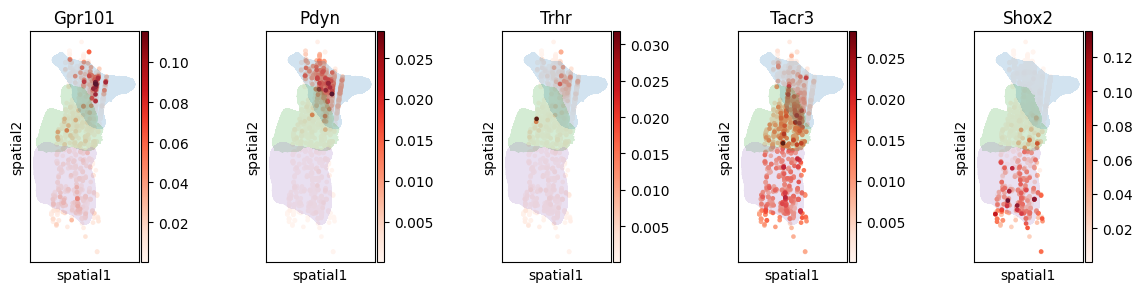

In [6]:
with plt.rc_context({"figure.figsize": (3,3)}):    
    ax = sc.pl.embedding(adata_mer, dimensions = (2, 1),basis="spatial", cmap ='Reds',
                         color=intersted_genes,ncols =5, show=False)    
    for a in ax:
        a.triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .2, label = 'LC')
        a.triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .2, label = 'CD')
        a.triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .2, label = 'CV')
        a.invert_yaxis()
        a.set_aspect('equal')
    plt.tight_layout()
    
with plt.rc_context({"figure.figsize": (2,3)}):    
    ax = sc.pl.embedding(adata_mer, dimensions = (0, 1),basis="spatial", cmap ='Reds',
                         color=intersted_genes,ncols =5, show=False)    
    for a in ax:
        a.triplot(mesh_LC.vertices.T[0], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .2, label = 'LC')
        a.triplot(mesh_CD.vertices.T[0], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .2, label = 'CD')
        a.triplot(mesh_CV.vertices.T[0], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .2, label = 'CV')
        a.invert_yaxis()
        a.set_aspect('equal')
    plt.tight_layout()

# run CCA and get the vector of interest. 
from `07_CCA` notebook 

In [7]:
def set_axes_equal(ax):
    """
    Set equal scaling for a 3D plot so that spheres appear as spheres,
    not ellipsoids. This function adjusts the x, y, and z limits of the axis.
    """
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()

    x_range = abs(x_limits[1] - x_limits[0])
    x_middle = np.mean(x_limits)
    y_range = abs(y_limits[1] - y_limits[0])
    y_middle = np.mean(y_limits)
    z_range = abs(z_limits[1] - z_limits[0])
    z_middle = np.mean(z_limits)

    # Determine the maximum range among all axes.
    plot_radius = 0.5 * max([x_range, y_range, z_range])

    ax.set_xlim3d([x_middle - plot_radius, x_middle + plot_radius])
    ax.set_ylim3d([y_middle - plot_radius, y_middle + plot_radius])
    ax.set_zlim3d([z_middle - plot_radius, z_middle + plot_radius])


In [8]:

cca_w = np.array([[-0.99686632, -0.05273333, -0.05896389],
       [ 0.05737438, -0.99514184, -0.08000562],
       [-0.05445847, -0.08313792,  0.99504892]])

direction_of_interest_1 = -cca_w[:,0]
direction_of_interest_2 = -cca_w[:,1]

In [9]:
np.sum(direction_of_interest**2)

NameError: name 'direction_of_interest' is not defined

In [ ]:
from mpl_toolkits.mplot3d import Axes3D 
import matplotlib.pyplot as plt
import numpy as np

coords = adata_mer.obsm['spatial']
coords_trans = np.column_stack((coords[:,0], coords[:,2], coords[:,1]))

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(coords_trans[:,0], coords_trans[:,1], coords_trans[:,2],
           alpha=0.1, s=3)

d1 = direction_of_interest_1 / np.linalg.norm(direction_of_interest_1)
d2 = direction_of_interest_2 / np.linalg.norm(direction_of_interest_2)
d1_trans = np.array([d1[0], d1[2], d1[1]])
d2_trans = np.array([d2[0], d2[2], d2[1]])

origin = np.mean(coords_trans, axis=0)
arrow_length = 50
ax.quiver(origin[0], origin[1], origin[2],
          d1_trans[0], d1_trans[1], d1_trans[2],
          length=arrow_length, color='red',
          arrow_length_ratio=0.4, label='first canonical vector')
ax.quiver(origin[0], origin[1], origin[2],
          d2_trans[0], d2_trans[1], d2_trans[2],
          length=arrow_length, color='blue',
          arrow_length_ratio=0.4, label='second canonical vector')

# Update axis labels accordingly: now X, Z, Y.
ax.set_xlabel('X')
ax.set_ylabel('Z')
ax.set_zlabel('Y')
ax.legend()
set_axes_equal(ax)

ax.plot_trisurf(mesh_LC.vertices[:,0],mesh_LC.vertices[:,2],mesh_LC.vertices[:,1],triangles=mesh_LC.faces,alpha=0.1, 
                edgecolor='none', label='LC', color = 'lightblue')
ax.plot_trisurf(mesh_CD.vertices[:,0],mesh_CD.vertices[:,2],mesh_CD.vertices[:,1],triangles=mesh_CD.faces,alpha=0.1, 
                edgecolor='none', label='CD', color = 'lightgreen')
ax.plot_trisurf(mesh_CV.vertices[:,0],mesh_CV.vertices[:,2],mesh_CV.vertices[:,1],triangles=mesh_CV.faces,alpha=0.1, 
                edgecolor='none', label='CV', color = 'purple')
ax.view_init(elev=20, azim=30)


plt.show()



In [ ]:
import plotly.graph_objects as go
centerpoint = np.array(np.mean(mesh_LC.vertices,0))
k = 1
scale_factor = 50  # adjust as needed
vector = cca_w[:, k]         # vector is 3D
spatial = adata_mer.obsm['spatial']

arrow_orig = centerpoint
arrow_end = arrow_orig + vector*scale_factor

arrow_length = np.linalg.norm(vector*10)
arrowhead_length = arrow_length * 0.1  # Arrowhead length as 10% of the arrow length
normalized_vector = vector / arrow_length
arrowhead_vector = normalized_vector * arrowhead_length

# Create a 3D scatter plot for the spatial points
scatter = go.Scatter3d(
    x=spatial[:, 0],
    y=spatial[:, 1],
    z=spatial[:, 2],
    mode='markers',
    marker=dict(size=3, color='lightblue', opacity=0.8),
    name='Spatial Points'
)

# Create the arrow shaft as a line from arrow_orig to arrow_end
shaft = go.Scatter3d(
    x=[arrow_orig[0], arrow_end[0]],
    y=[arrow_orig[1], arrow_end[1]],
    z=[arrow_orig[2], arrow_end[2]],
    mode='lines',
    line=dict(color='blue', width=5),
    name='CCA2'
)

# Create the arrowhead as a cone
arrowhead = go.Cone(
    x=[arrow_end[0]],
    y=[arrow_end[1]],
    z=[arrow_end[2]],
    u=[arrowhead_vector[0]],
    v=[arrowhead_vector[1]],
    w=[arrowhead_vector[2]],
    anchor="tip",  # The cone tip is placed at arrow_end
    colorscale=[[0, 'blue'], [1, 'blue']],
    showscale=False,
    sizemode="absolute",
    sizeref=10  # Control the size of the cone
)

fig = go.Figure(data=[scatter, shaft, arrowhead])
fig.update_layout(
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        aspectmode='data'),
    title="Interactive 3D Plot with Arrow",
    width=800,
    height=800
)

for mesh in allmeshes:
    x, y, z = mesh.vertices.T
    i, j, k = np.asarray(mesh.faces).T
    fig.add_trace(go.Mesh3d(x=x, y=y, z=z,i=i, j=j, k=k, opacity = .1))

fig.show()


In [ ]:
from scipy.stats import spearmanr, pearsonr

In [ ]:
# Normalize the direction vector - its not necessary bc its already normalized
direction_norm = direction_of_interest / np.linalg.norm(direction_of_interest)

# Project each cell’s spatial coordinate onto the direction
projected = adata_mer.obsm['spatial'] @ direction_norm

if hasattr(adata_mer.X, 'toarray'):
    X = adata_mer.X.toarray()
else:
    X = np.array(adata_mer.X)
gene_names = adata_mer.var_names
results = []
for i, gene in enumerate(gene_names):
    expr = X[:, i]
    corr, pval = spearmanr(expr, projected)
    results.append((gene, corr, pval))

df_results = pd.DataFrame(results, columns=['gene', 'spearman_corr', 'p_value'])
df_results_sorted = df_results.sort_values(by='spearman_corr', key=lambda s: s.abs(), ascending=False)

print(df_results_sorted.head(15))

In [ ]:
print(df_results_sorted.tail(5))

In [55]:
newly_found = list(df_results_sorted['gene'])


In [57]:
[newly_found.remove(g) for g in intersted_genes]

[None, None, None, None, None]

/scratch/fast/50851/ipykernel_2105369/2716787291.py:11: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



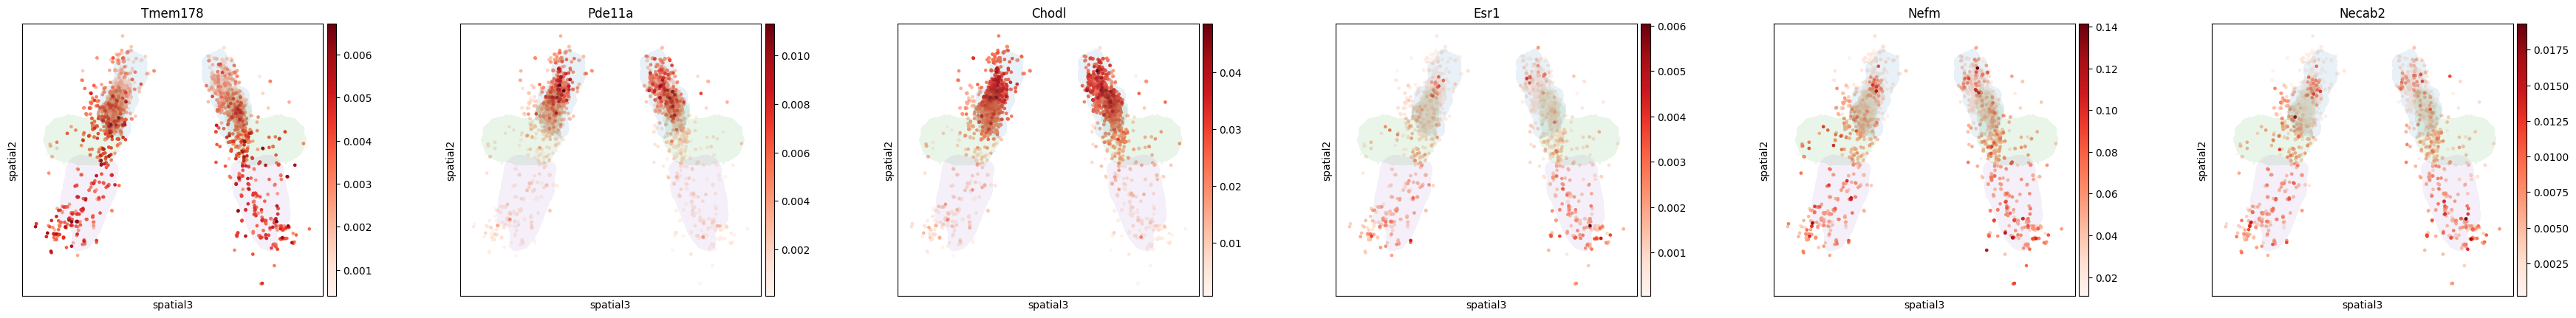

In [63]:
T = 6

ax = sc.pl.embedding(adata_mer, color=newly_found[:T], 
                     basis='spatial', dimensions = (2,1),show = False, cmap = 'Reds', ncols = T)
for a in ax:
    a.set_aspect('equal')
    a.invert_yaxis()
    a.triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
    a.triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
    a.triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
plt.tight_layout()    

/scratch/fast/50851/ipykernel_2105369/1739266260.py:10: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



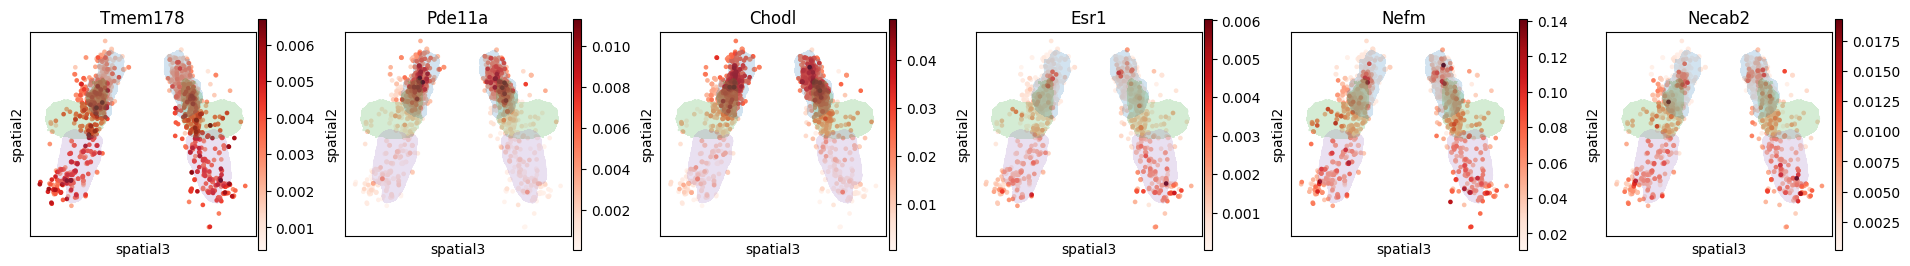

In [64]:
with plt.rc_context({"figure.figsize": (3,3)}):    
    ax = sc.pl.embedding(adata_mer, dimensions = (2, 1),basis="spatial", cmap ='Reds',
                         color=newly_found[:T], ncols =T, show=False)    
    for a in ax:
        a.triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .2, label = 'LC')
        a.triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .2, label = 'CD')
        a.triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .2, label = 'CV')
        a.invert_yaxis()
        a.set_aspect('equal')
    plt.tight_layout()

/scratch/fast/50851/ipykernel_2105369/4125633857.py:10: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



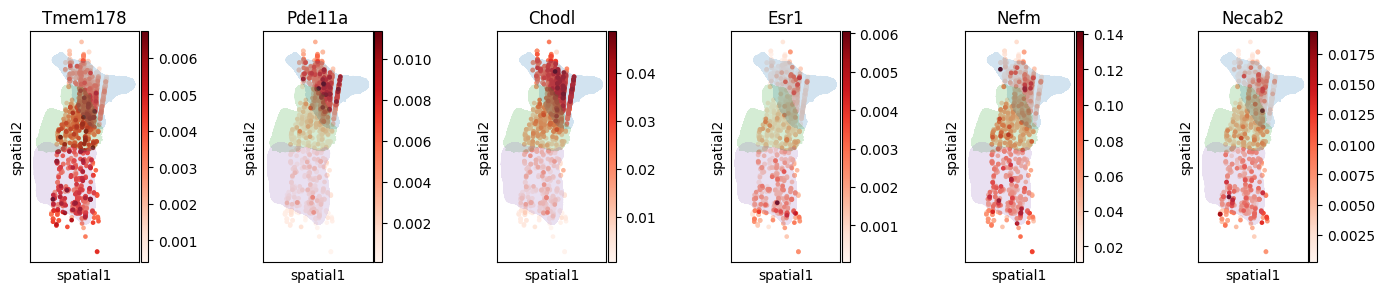

In [65]:
with plt.rc_context({"figure.figsize": (2,3)}):    
    ax = sc.pl.embedding(adata_mer, dimensions = (0, 1),basis="spatial", cmap ='Reds',
                         color=newly_found[:T], ncols =T, show=False)    
    for a in ax:
        a.triplot(mesh_LC.vertices.T[0], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .2, label = 'LC')
        a.triplot(mesh_CD.vertices.T[0], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .2, label = 'CD')
        a.triplot(mesh_CV.vertices.T[0], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .2, label = 'CV')
        a.invert_yaxis()
        a.set_aspect('equal')
    fig.tight_layout()

# just look at teh DV axis. 

In [17]:


dv = adata_mer.obsm['spatial'][:, 1]

if hasattr(adata_mer.X, "toarray"):
    X = adata_mer.X.toarray()
else:
    X = np.array(adata_mer.X)
gene_names = adata_mer.var_names
results = []
for i, gene in enumerate(gene_names):
    expr = X[:, i]
    corr, pval = spearmanr(expr, dv)
#     corr, pval = peasonr(expr, dv)
    results.append((gene, corr, pval))
df_results = pd.DataFrame(results, columns=['gene', 'spearman_corr', 'p_value'])
df_results_sorted = df_results.sort_values(by='spearman_corr', key=lambda s: s.abs(), ascending=False)
print(df_results_sorted.head(15))

        gene  spearman_corr        p_value
269    Tacr3       0.712876   0.000000e+00
197     Pdyn      -0.681110   0.000000e+00
275  Tmem178       0.647081  2.059724e-314
194   Pde11a      -0.622296  4.473882e-284
44     Chodl      -0.602568  8.179423e-262
86      Esr1       0.584872  3.959172e-243
163     Nefm       0.558428  2.893964e-217
160   Necab2       0.538060  7.066142e-199
198    Pdzd2       0.529954  6.639479e-192
101    Galr1       0.507549  1.378806e-173
237    Shox2       0.486164  2.468009e-157
296  Zfp804b       0.476958  1.099999e-150
203     Pon2      -0.467064  9.185597e-144
161     Nefh       0.460629  2.211656e-139
31     Calcr      -0.457801  1.741042e-137


/home/shuonan.chen/miniconda3/envs/allensdk/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



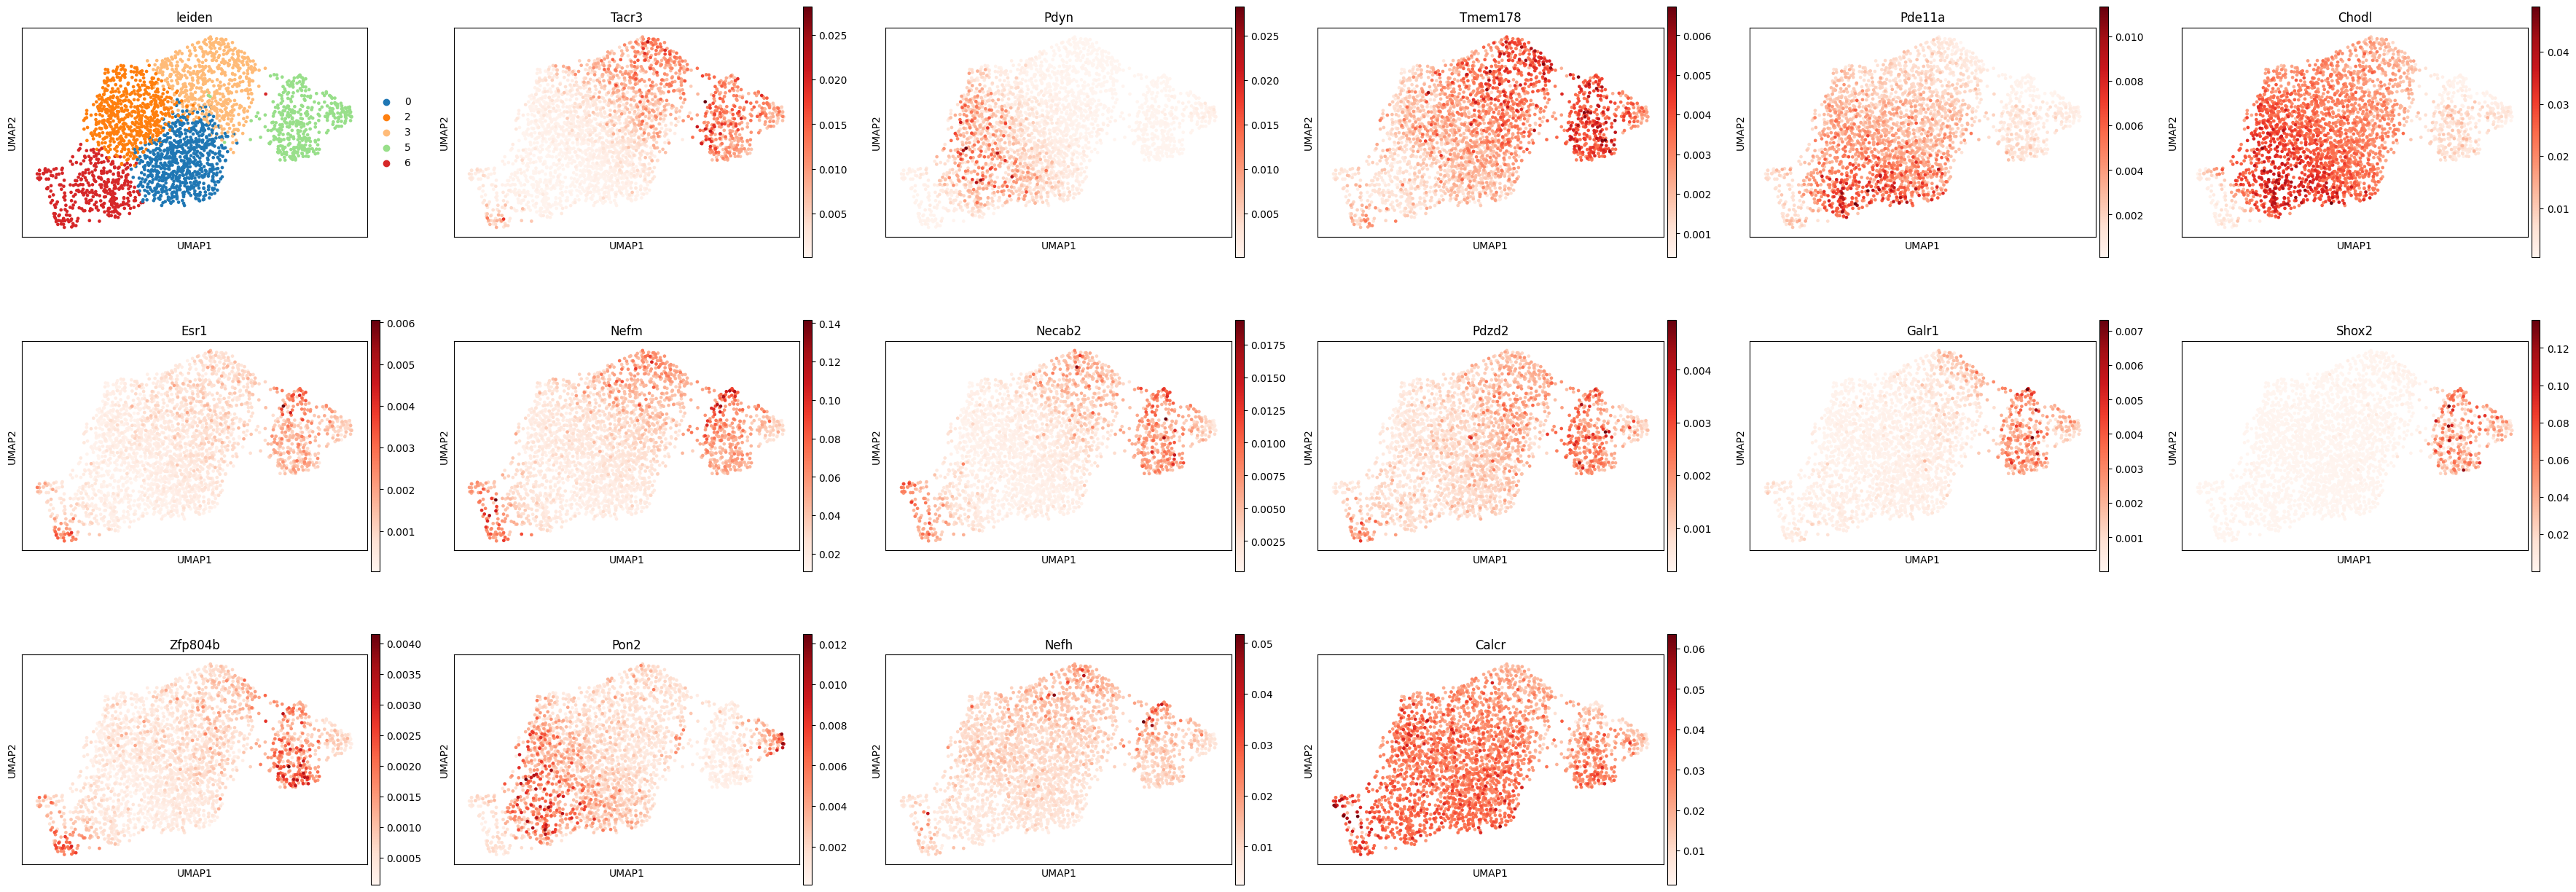

In [18]:
ax = sc.pl.umap(adata_mer, color=['leiden'] +list(df_results_sorted['gene'][:T]), 
                show = False, cmap = 'Reds', ncols = 6)
for a in ax:
    a.set_aspect('equal')

/home/shuonan.chen/miniconda3/envs/allensdk/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



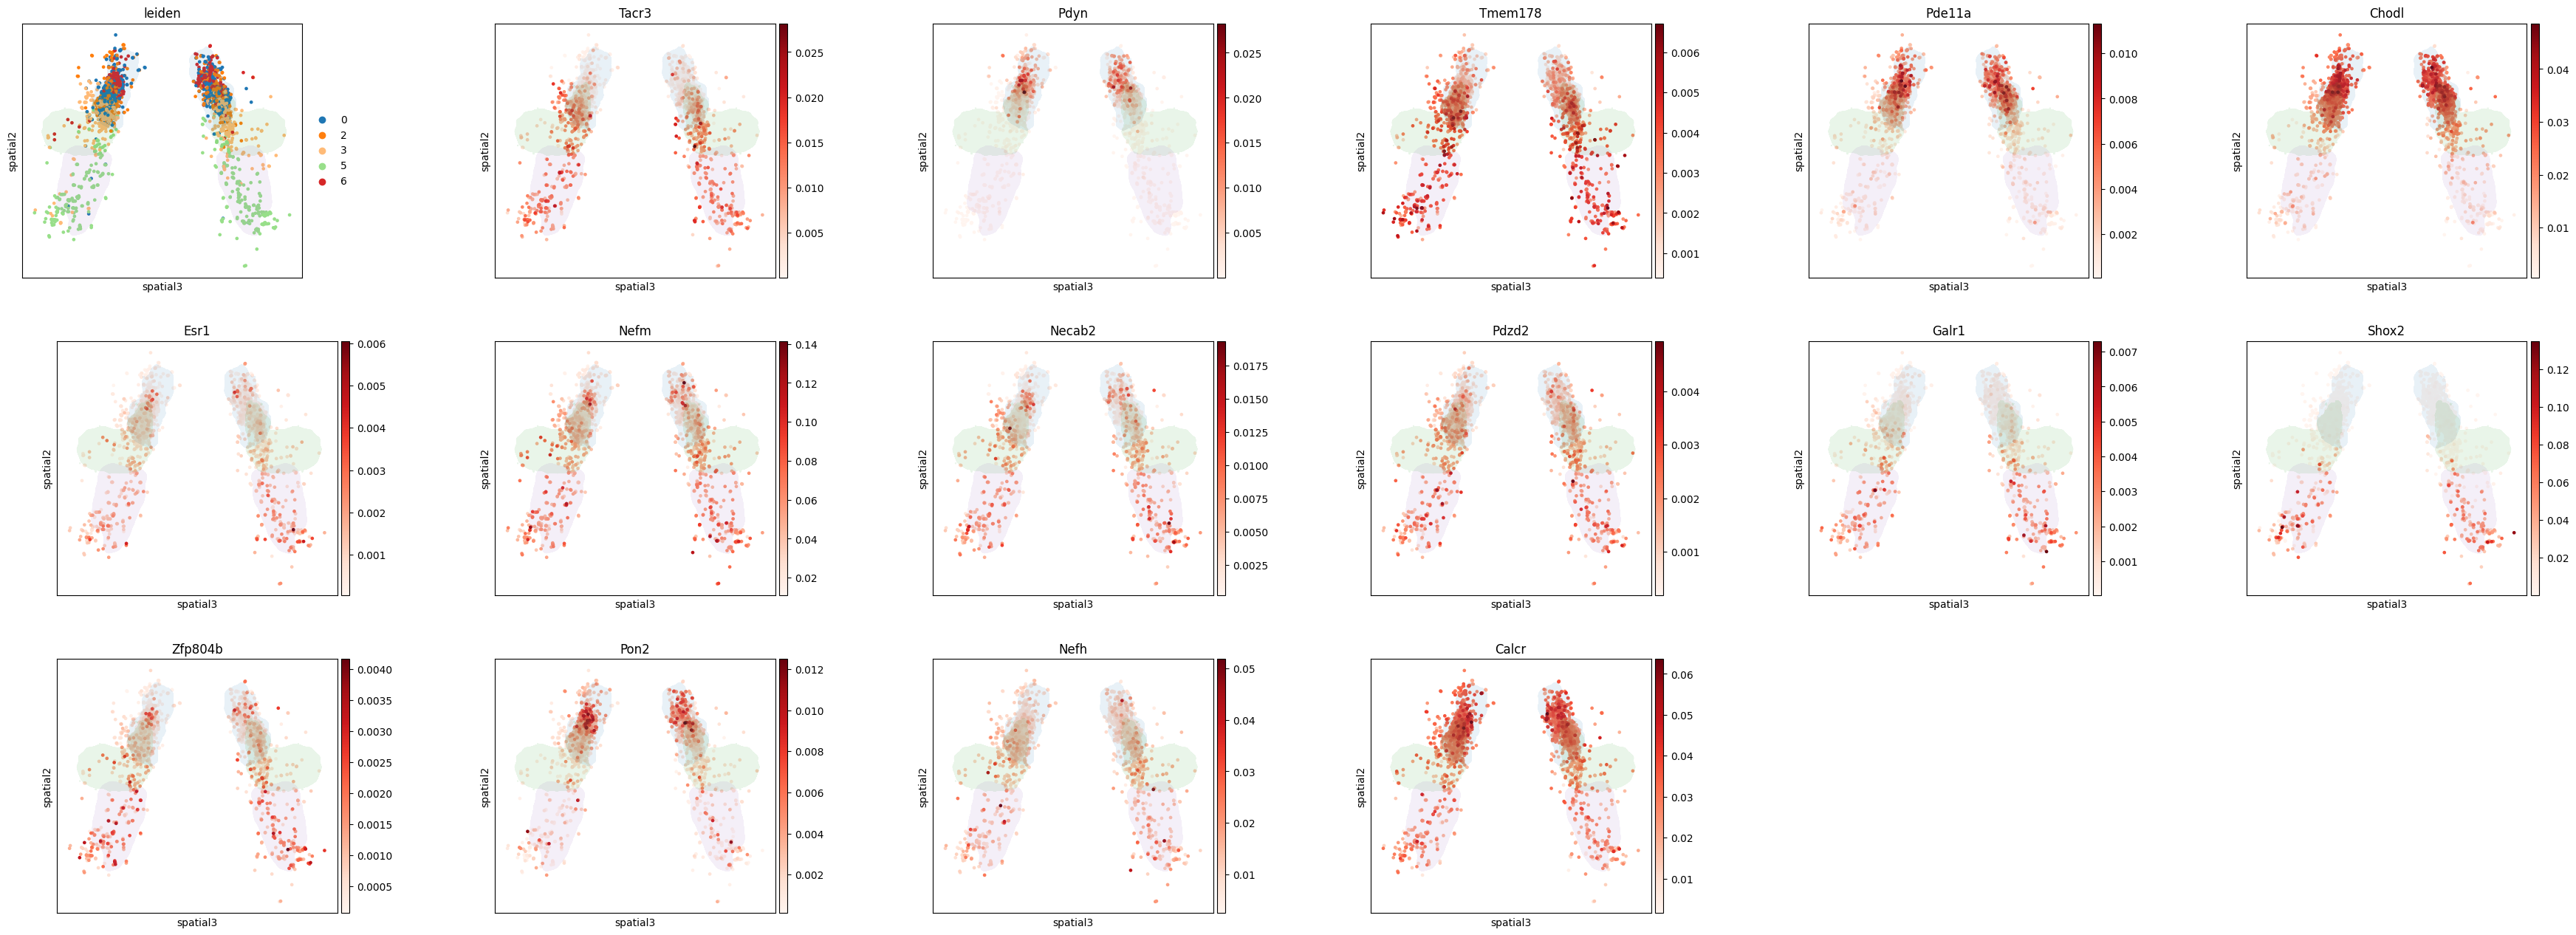

In [19]:
ax = sc.pl.embedding(adata_mer, color=['leiden'] +list(df_results_sorted['gene'][:T]), 
                     basis='spatial', dimensions = (2,1),show = False, cmap = 'Reds', ncols = 6)
for a in ax:
    a.set_aspect('equal')
    a.invert_yaxis()
    a.triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
    a.triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
    a.triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')